In [4]:
print("Fetching pre-compiled GBM from Ubuntu servers...")
system("sudo apt-get update", intern=TRUE)
system("sudo apt-get install -y r-cran-gbm", intern=TRUE)

required_packages <- c("randomForest", "gbm", "e1071", "tree", "pls", "splines",
                       "glmnet", "leaps", "boot")

# Loop through, install if missing, and load them
for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg, repos = "http://cran.us.r-project.org", quiet = TRUE)
    library(pkg, character.only = TRUE)
  }
}

library(gbm)
print("All packages successfully installed and loaded.")


[1] "Fetching pre-compiled GBM from Ubuntu servers..."


[1] "Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease"                                           
 [2] "Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]"                        
 [3] "Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]"                          
 [4] "Get:4 https://cli.github.com/packages stable InRelease [3,917 B]"                                 
 [5] "Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]"             
 [6] "Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]"                             
 [7] "Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]"                        
 [8] "Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,049 kB]"            
 [9] "Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]"           
[10] "Get:10 https://cli.github.com/packages stable/main amd64 Packages [354 B]"                        
[11] "Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,258 kB]"     
[12] "Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease"                     
[13] "Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,308 kB]"       
[14] "Get:14 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]"             
[15] "Get:15 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]"         
[16] "Get:16 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,568 kB]"       
[17] "Get:17 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,089 kB]"                 
[18] "Get:18 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,404 kB]"             
[19] "Get:19 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]"                    
[20] "Get:20 http://archive.ubuntu.com/ubuntu jammy-backports/universe amd64 Packages [35.6 kB]"        
[21] "Get:21 http://archive.ubuntu.com/ubuntu jammy-backports/main amd64 Packages [82.8 kB]"            
[22] "Get:22 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.6 kB]"
[23] "Fetched 40.4 MB in 4s (10.8 MB/s)"                                                                
[24] "Reading package lists..."

[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
 [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
 [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
 [4] "Suggested packages:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
 [5] "  r-cran-covr r-cran-gridextra r-cran-pdp r-cran-runit r-cran-tinytest"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
 [6] "  r-cran-vip r-cran-viridis"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
 [7] "The following NEW packages will be installed:"                                                                         

Loading required package: gbm

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Loading required package: e1071



[1] "All packages successfully installed and loaded."
[1] "All packages successfully installed and loaded."


In [5]:
df <- read.csv("IBM-Employee-Attrition.csv", header=TRUE, stringsAsFactors=TRUE)
df <- na.omit(df)
nrow(df)
names(df)

df$Attrition <- as.factor(df$Attrition)
df$Education <- as.factor(df$Education)
df$BusinessTravel <- as.factor(df$BusinessTravel)
df$EducationField <- as.factor(df$EducationField)
df$Department <- as.factor(df$Department)
df$EnvironmentSatisfaction <- as.factor(df$EnvironmentSatisfaction)
df$Gender <- as.factor(df$Gender)
df$JobInvolvement <- as.factor(df$JobInvolvement)
df$JobLevel <- as.factor(df$JobLevel)
df$JobRole <- as.factor(df$JobRole)
df$JobSatisfaction <- as.factor(df$JobSatisfaction)
df$MaritalStatus <- as.factor(df$MaritalStatus)
df$OverTime <- as.factor(df$OverTime)
df$PerformanceRating <- as.factor(df$PerformanceRating)
df$RelationshipSatisfaction <- as.factor(df$RelationshipSatisfaction)
df$StockOptionLevel <- as.factor(df$StockOptionLevel)
df$WorkLifeBalance <- as.factor(df$WorkLifeBalance)

# fully constant column
df$EmployeeCount <- NULL
df$StandardHours <- NULL
# empty data
df$OverTime <- NULL

[1] 1470

[1] "Age"                      "Attrition"               
 [3] "BusinessTravel"           "DailyRate"               
 [5] "Department"               "DistanceFromHome"        
 [7] "Education"                "EducationField"          
 [9] "EmployeeCount"            "EmployeeNumber"          
[11] "EnvironmentSatisfaction"  "Gender"                  
[13] "HourlyRate"               "JobInvolvement"          
[15] "JobLevel"                 "JobRole"                 
[17] "JobSatisfaction"          "MaritalStatus"           
[19] "MonthlyIncome"            "MonthlyRate"             
[21] "NumCompaniesWorked"       "OverTime"                
[23] "PercentSalaryHike"        "PerformanceRating"       
[25] "RelationshipSatisfaction" "StandardHours"           
[27] "StockOptionLevel"         "TotalWorkingYears"       
[29] "TrainingTimesLastYear"    "WorkLifeBalance"         
[31] "YearsAtCompany"           "YearsInCurrentRole"      
[33] "YearsSinceLastPromotion"  "YearsWithCurrManager"

In [6]:
kfold <- function(data, fit) {
  # cost function will calculate MSE by default
  return(cv.glm(data = data, fit, K = 10)$delta[1])
}
select <- function(method) {
  # select model and identify best using method and adjr2
  selection <- regsubsets(MonthlyIncome ~ ., data = df, method = method)
  selection_summary <- summary(selection)
  best_selection <- which.max(selection_summary$adjr2)
  # Compute test MSE by running lm on best model
  # get the variables that matter from summary, [-1] to remove intercept
  vars <- names(coef(selection, best_selection))[-1]
  # since region is a factor variable, running it normally gives an error
  # because df does not recognize categorical vars. I solve this by making
  # a new matrix that does have categorical vars
  new_data <- model.matrix(MonthlyIncome ~ ., data = df)[, vars]
  cv_df <- data.frame(MonthlyIncome = df$MonthlyIncome, new_data)
  best_model <- glm(MonthlyIncome ~ ., data = cv_df)
  # run kfold on df, including region2, region3 variables
  # append the result to tab, we tabulate the result and print at the end
  return(list(mse = kfold(cv_df, best_model), model = selection,
  best_id = best_selection))
}
regress <- function(alpha, flg) {
  x <- model.matrix(MonthlyIncome ~ ., data = df)[, -1]
  y <- df$MonthlyIncome
  # grid of values from lambda = 1/100 to 10e10
  grid <- 10^seq(10, -2, length = 100)
  # glm automatically standardizes, if the assignment wanted non-std variables
  # we would add standardize = FALSE)
  # mod exists so we can get the coefficients once we tabulate
  mod <- glmnet(x, y, alpha = alpha, lambda = grid)
  # cross validation for lambda
  set.seed(1)
  cv.out <- cv.glmnet(x, y, alpha = alpha, nfolds = nrow(df))
  bestlam <- cv.out$lambda.min
  min_mse <- min(cv.out$cvm)
  bestlam
  # append the result to tab, we tabulate the result and print at the end
  if(flg){
    return(list(mse = min_mse, model = mod, bestlam = bestlam))
  }
  else{
    print(min_mse)
  }
}

# full model
fit_full <- glm(MonthlyIncome ~ ., data = df)
mse_full <- kfold(df, fit_full)
forward <- select("forward")
backward <- select("backward")
# 0 is ridge, 1 is lasso
ridge <- regress(0, TRUE)
lasso <- regress(1, TRUE)

# tabular summary
model_names <- c("Full", "Forward", "Backward", "Ridge", "Lasso")
mse <- c(mse_full, forward$mse, backward$mse, ridge$mse, lasso$mse)
coef_full <- coef(fit_full)
coef_fwd <- coef(forward$model, forward$best_id)
coef_bkwd <- coef(backward$model, backward$best_id)
coef_ridge <- as.numeric(coef(ridge$model, s = ridge$bestlam))
coef_lasso <- as.numeric(coef(lasso$model, s = lasso$bestlam))
names(coef_ridge) <- names(coef_full)
names(coef_lasso) <- names(coef_full)
vars <- names(coef_full)

sum_tab <- matrix(NA, nrow = 5, ncol = 64)
rownames(sum_tab) <- model_names
test_tab <- c("Test_MSE", vars)
print(test_tab)

colnames(sum_tab) <- c("Test_MSE", vars)
sum_tab[, "Test_MSE"] <- mse
sum_tab["Full", names(coef_full)] <- coef_full
sum_tab["Forward", names(coef_fwd)] <- coef_fwd
sum_tab["Backward", names(coef_bkwd)] <- coef_bkwd
sum_tab["Ridge", names(coef_ridge)] <- coef_ridge
sum_tab["Lasso", names(coef_lasso)] <- coef_lasso
summary_df <- as.data.frame(sum_tab)
print(summary_df)

Warning message:
“Option grouped=FALSE enforced in cv.glmnet, since < 3 observations per fold”
Warning message:
“Option grouped=FALSE enforced in cv.glmnet, since < 3 observations per fold”


 [1] "Test_MSE"                         "(Intercept)"                     
 [3] "Age"                              "AttritionYes"                    
 [5] "BusinessTravelTravel_Frequently"  "BusinessTravelTravel_Rarely"     
 [7] "DailyRate"                        "DepartmentResearch & Development"
 [9] "DepartmentSales"                  "DistanceFromHome"                
[11] "Education2"                       "Education3"                      
[13] "Education4"                       "Education5"                      
[15] "EducationFieldLife Sciences"      "EducationFieldMarketing"         
[17] "EducationFieldMedical"            "EducationFieldOther"             
[19] "EducationFieldTechnical Degree"   "EmployeeNumber"                  
[21] "EnvironmentSatisfaction2"         "EnvironmentSatisfaction3"        
[23] "EnvironmentSatisfaction4"         "GenderMale"                      
[25] "HourlyRate"                       "JobInvolvement2"                 
[27] "JobInvolvement3"   

Data: 	X dimension: 1470 62 
	Y dimension: 1470 1
Fit method: svdpc
Number of components considered: 62

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV            4710     2907     2902     2899     2491     2451     2446
adjCV         4710     2904     2901     2901     2483     2431     2443
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV        2403     2389     2320      2312      2304      2306      2307
adjCV     2392     2391     2305      2305      2296      2300      2305
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV         2304      2306      2294      2290      2269      2245      2215
adjCV      2301      2305      2293      2305      2272      2241      2188
       21 comps  22 comps  23 comps  24 comps  25 comps  26 comps  27 comps
CV         2202      2188      2124      2092      2061      2043      2021
adjCV      2194  

,PC1,PC2
Age,0.5886683191,-0.089827422
DailyRate,-0.0031150351,-0.034860688
DistanceFromHome,0.0009668175,0.041259350
EmployeeNumber,-0.0183853243,0.037730060
HourlyRate,-0.0157362234,-0.019306250
MonthlyRate,0.0047939557,0.017992899
NumCompaniesWorked,0.0778180375,-0.055580053
PercentSalaryHike,-0.0258746553,-0.057920710
TotalWorkingYears,0.8489862567,-0.110994753
TrainingTimesLastYear,-0.0213799917,0.019389288


           PC1         PC2
[1,] 0.5886683 -0.08982742
           PC1         PC2
[1,] 0.8462861 -0.02314164


Age                     AttritionYes 
                    0.2772732714                    -0.1160104238 
 BusinessTravelTravel_Frequently      BusinessTravelTravel_Rarely 
                   -0.0137634785                     0.0116137404 
                       DailyRate DepartmentResearch & Development 
                   -0.0014672370                    -0.0397459403 
                 DepartmentSales                 DistanceFromHome 
                    0.0405789218                     0.0004553883 
                      Education2                       Education3 
                   -0.0212202546                    -0.0107836616 
                      Education4                       Education5 
                    0.0474309096                     0.0410272664 
     EducationFieldLife Sciences          EducationFieldMarketing 
                   -0.0013835476                     0.0436576685 
           EducationFieldMedical              EducationFieldOther 
                   -0.0034559715                    -0.0224870116 
  EducationFieldTechnical Degree                   EmployeeNumber 
                   -0.0220603607                    -0.0086598155 
        EnvironmentSatisfaction2         EnvironmentSatisfaction3 
                   -0.0031919033                     0.0069002939 
        EnvironmentSatisfaction4                       GenderMale 
                   -0.0007656063                    -0.0303782466 
                      HourlyRate                  JobInvolvement2 
                   -0.0074120417                    -0.0030807350 
                 JobInvolvement3                  JobInvolvement4 
                    0.0104646635                    -0.0043371458 
                       JobLevel2                        JobLevel3 
                   -0.0287877846                     0.1234745931 
                       JobLevel4                        JobLevel5 
                    0.2224236698                     0.2002250592 
          JobRoleHuman Resources     JobRoleLaboratory Technician 
                   -0.0361234841                    -0.1259395887 
                  JobRoleManager    JobRoleManufacturing Director 
                    0.2380293297                     0.0276586279 
        JobRoleResearch Director        JobRoleResearch Scientist 
                    0.1447242459                    -0.1305127448 
          JobRoleSales Executive      JobRoleSales Representative 
                    0.0469974538                    -0.1052532256 
                JobSatisfaction2                 JobSatisfaction3 
                    0.0025187856                    -0.0033966800 
                JobSatisfaction4             MaritalStatusMarried 
                   -0.0037519481                     0.0704320876 
             MaritalStatusSingle                      MonthlyRate 
                   -0.0910882887                     0.0022580386 
              NumCompaniesWorked                PercentSalaryHike 
                    0.0366536828                    -0.0121874239 
              PerformanceRating4        RelationshipSatisfaction2 
                    0.0039039550                    -0.0077641629 
       RelationshipSatisfaction3        RelationshipSatisfaction4 
                   -0.0158139643                     0.0257642874 
               StockOptionLevel1                StockOptionLevel2 
                    0.0839924962                    -0.0044398350 
               StockOptionLevel3                TotalWorkingYears 
                   -0.0153048852                     0.3998876602 
           TrainingTimesLastYear                 WorkLifeBalance2 
                   -0.0100703572                     0.0003195829 
                WorkLifeBalance3                 WorkLifeBalance4 
                    0.0044886597                     0.0036691057 
                  YearsAtCompany               YearsInCurrentRole 
                    0.3986158416                     0.3438965675 
         

Age                     AttritionYes 
                    -0.047280461                      0.059087716 
 BusinessTravelTravel_Frequently      BusinessTravelTravel_Rarely 
                     0.008807177                     -0.011212110 
                       DailyRate DepartmentResearch & Development 
                    -0.018348845                     -0.483252539 
                 DepartmentSales                 DistanceFromHome 
                     0.494574776                      0.021716766 
                      Education2                       Education3 
                     0.006368439                     -0.028415586 
                      Education4                       Education5 
                     0.028046913                      0.006642522 
     EducationFieldLife Sciences          EducationFieldMarketing 
                    -0.080170820                      0.341425982 
           EducationFieldMedical              EducationFieldOther 
                    -0.121630078                     -0.028465804 
  EducationFieldTechnical Degree                   EmployeeNumber 
                    -0.017403213                      0.019859132 
        EnvironmentSatisfaction2         EnvironmentSatisfaction3 
                     0.029924775                      0.002426135 
        EnvironmentSatisfaction4                       GenderMale 
                    -0.024966659                     -0.014471527 
                      HourlyRate                  JobInvolvement2 
                    -0.010161801                     -0.003991518 
                 JobInvolvement3                  JobInvolvement4 
                     0.018976498                     -0.033346495 
                       JobLevel2                        JobLevel3 
                     0.196341001                      0.035753906 
                       JobLevel4                        JobLevel5 
                    -0.050444315                     -0.074054567 
          JobRoleHuman Resources     JobRoleLaboratory Technician 
                     0.020302760                     -0.166491474 
                  JobRoleManager    JobRoleManufacturing Director 
                    -0.039745564                     -0.101630769 
        JobRoleResearch Director        JobRoleResearch Scientist 
                    -0.120615208                     -0.184036711 
          JobRoleSales Executive      JobRoleSales Representative 
                     0.441923369                      0.159501405 
                JobSatisfaction2                 JobSatisfaction3 
                     0.010864471                     -0.027331026 
                JobSatisfaction4             MaritalStatusMarried 
                     0.017599663                     -0.004272071 
             MaritalStatusSingle                      MonthlyRate 
                     0.024774223                      0.009470522 
              NumCompaniesWorked                PercentSalaryHike 
                    -0.029254435                     -0.030486435 
              PerformanceRating4        RelationshipSatisfaction2 
                    -0.033558976                     -0.040774934 
       RelationshipSatisfaction3        RelationshipSatisfaction4 
                    -0.011024749                      0.020540031 
               StockOptionLevel1                StockOptionLevel2 
                    -0.029366533                      0.026104582 
               StockOptionLevel3                TotalWorkingYears 
                    -0.014038595                     -0.058421838 
           TrainingTimesLastYear                 WorkLifeBalance2 
                     0.010205508                     -0.022122462 
                WorkLifeBalance3                 WorkLifeBalance4 
                     0.020448029                      0.018121245 
                  YearsAtCompany               YearsInCurrentRole 
                    -0.012180549                      0.009383215 
         

 [1] "Age"                      "Attrition"               
 [3] "BusinessTravel"           "DailyRate"               
 [5] "Department"               "DistanceFromHome"        
 [7] "Education"                "EducationField"          
 [9] "EmployeeNumber"           "EnvironmentSatisfaction" 
[11] "Gender"                   "HourlyRate"              
[13] "JobInvolvement"           "JobLevel"                
[15] "JobRole"                  "JobSatisfaction"         
[17] "MaritalStatus"            "MonthlyIncome"           
[19] "MonthlyRate"              "NumCompaniesWorked"      
[21] "PercentSalaryHike"        "PerformanceRating"       
[23] "RelationshipSatisfaction" "StockOptionLevel"        
[25] "TotalWorkingYears"        "TrainingTimesLastYear"   
[27] "WorkLifeBalance"          "YearsAtCompany"          
[29] "YearsInCurrentRole"       "YearsSinceLastPromotion" 
[31] "YearsWithCurrManager"    


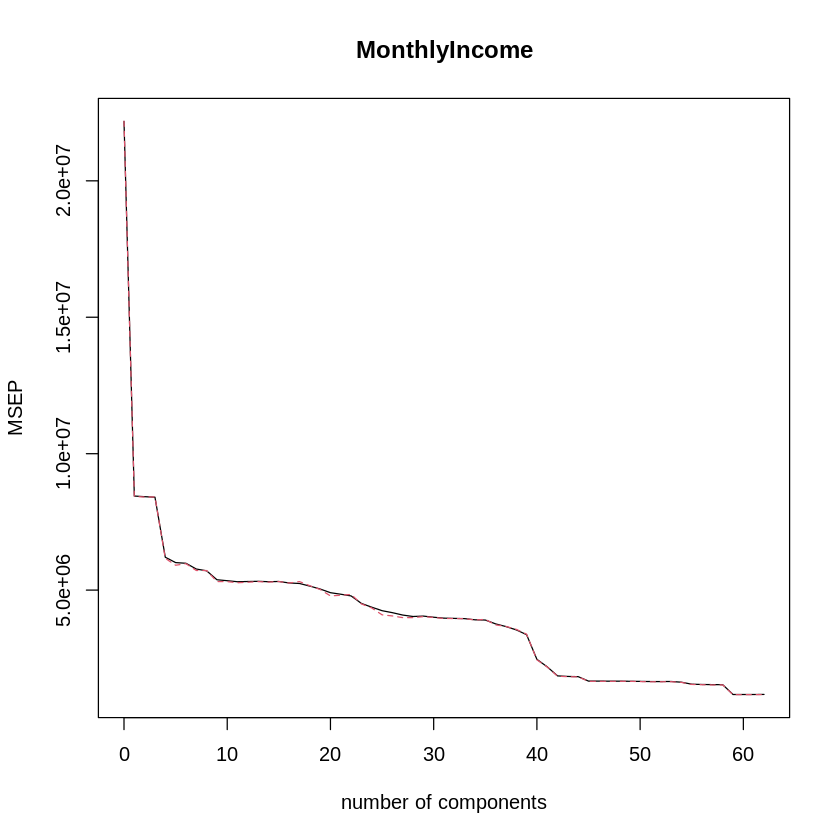

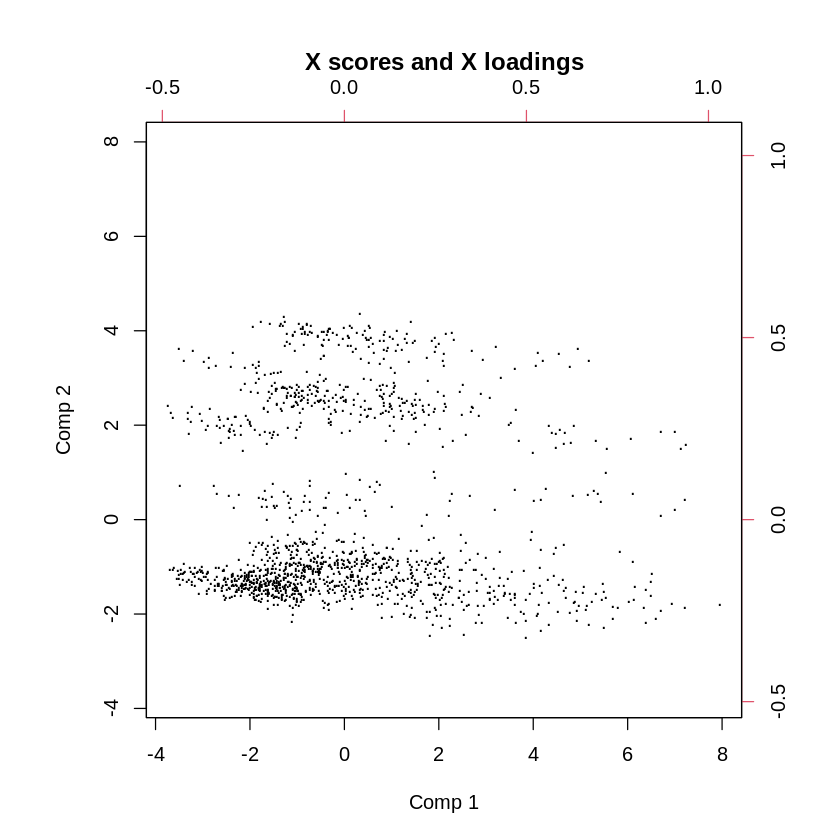

In [7]:
# Unsupervised reduction = PCR (not PLS)
set.seed(2)

# pca_subset <- prcomp(df[, -c(2, 3, 5, 7, 8, 10, 11, 13, 14, 15, 16,
#                           17, 22, 23, 24, 27)], scale. = TRUE)

pcr.fit <- pcr(MonthlyIncome ~ ., data = df, scale = TRUE, validation = "CV")
summary(pcr.fit)
validationplot(pcr.fit, val.type = "MSEP")

# only quantitative variables can be standardized
quant_vars <- df[, sapply(df, is.numeric)]
# dont standardize MonthlyIncome
quant_vars <- quant_vars[, colnames(quant_vars) != "MonthlyIncome"]
quant_scaled <- scale(quant_vars)

# Scores on the first two PCs
scores <- pcr.fit$scores[, 1:2]
colnames(scores) <- c("PC1", "PC2")
tab <- cor(quant_scaled, scores)
tab

# Correlations with PC1 and PC2
r_Age <- cor(df$Age, scores)
r_YearsAtCompany  <- cor(df$YearsAtCompany,  scores)

print(r_Age)
print(r_YearsAtCompany)

load <- loadings(pcr.fit)
load[, 1]
load[, 2]

print(colnames(df))

# replace names with dots since it was really messy otherwise

biplot(pcr.fit, comps = 1:2, xlabs = rep("·", nrow(df)),
       ylabs = rep("", length(prednames(pcr.fit))), var.axes = FALSE)


In [9]:
df$MonthlyIncome <- log(df$MonthlyIncome)
fit <- glm(MonthlyIncome ~ ., data = df)
cv <- kfold(df, fit)
# full MSE
cv

pcr_kfold <- pcr(MonthlyIncome ~ ., data = df, scale = TRUE, validation = "CV")

# Find M
# We have to subtract/add by 1 since the first item corresponds to 0 comps
cv.errors <- MSEP(pcr_kfold, estimate = "CV")
M <- which.min(cv.errors$val[1, 1, ]) - 1
M
# PCR error
cv.errors$val[1, 1, M + 1]

pls_kfold <- plsr(MonthlyIncome ~ ., data = df, scale = TRUE, validation = "CV")

# Find M
# We have to subtract/add by 1 since the first item corresponds to 0 comps
cv.errors <- MSEP(pls_kfold, estimate = "CV")
M <- which.min(cv.errors$val[1, 1, ]) - 1
M
# PLS error
cv.errors$val[1, 1, M + 1]

# 0 is ridge, 1 is Lasso, FALSE to just print the minimum MSE instead of
# making a list
regress(0, FALSE)

fit <- glm(MonthlyIncome ~ ., data = df)
summary(fit)


[1] 0.0007752677

59 comps 
      59

[1] 0.0007789472

15 comps 
      15

[1] 0.0007757551

Warning message:
“Option grouped=FALSE enforced in cv.glmnet, since < 3 observations per fold”


[1] 0.0008183556



Call:
glm(formula = MonthlyIncome ~ ., data = df)

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       2.081e+00  1.389e-02 149.849  < 2e-16 ***
Age                               6.331e-05  1.135e-04   0.558  0.57712    
AttritionYes                     -6.366e-03  2.212e-03  -2.878  0.00406 ** 
BusinessTravelTravel_Frequently   6.796e-03  2.836e-03   2.397  0.01668 *  
BusinessTravelTravel_Rarely       5.994e-03  2.438e-03   2.459  0.01406 *  
DailyRate                         1.497e-06  1.809e-06   0.828  0.40804    
DepartmentResearch & Development  2.052e-03  9.991e-03   0.205  0.83730    
DepartmentSales                  -2.435e-03  1.036e-02  -0.235  0.81422    
DistanceFromHome                 -2.016e-05  9.011e-05  -0.224  0.82298    
Education2                       -2.437e-03  2.736e-03  -0.891  0.37325    
Education3                       -2.825e-03  2.456e-03  -1.150  0.25027    
Education4            

[1] 15

[1] 0.002366093

node), split, n, deviance, yval
      * denotes terminal node

1) root 1470 8.76700 2.143  
  2) JobLevel: 1,2 1077 3.02900 2.107  
    4) JobLevel: 1 543 0.67440 2.066  
      8) TotalWorkingYears < 1.5 92 0.16490 2.029 *
      9) TotalWorkingYears > 1.5 451 0.36280 2.073 *
    5) JobLevel: 2 534 0.48690 2.149 *
  3) JobLevel: 3,4,5 393 0.46350 2.242  
    6) JobLevel: 3 218 0.09018 2.216 *
    7) JobLevel: 4,5 175 0.03886 2.275 *



Regression tree:
tree(formula = MonthlyIncome ~ ., data = mod_df)
Variables actually used in tree construction:
[1] "JobLevel"          "TotalWorkingYears"
Number of terminal nodes:  5 
Residual mean deviance:  0.0007807 = 1.144 / 1465 
Distribution of residuals:
      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-0.1181000 -0.0192900  0.0007986  0.0000000  0.0170900  0.0712600 

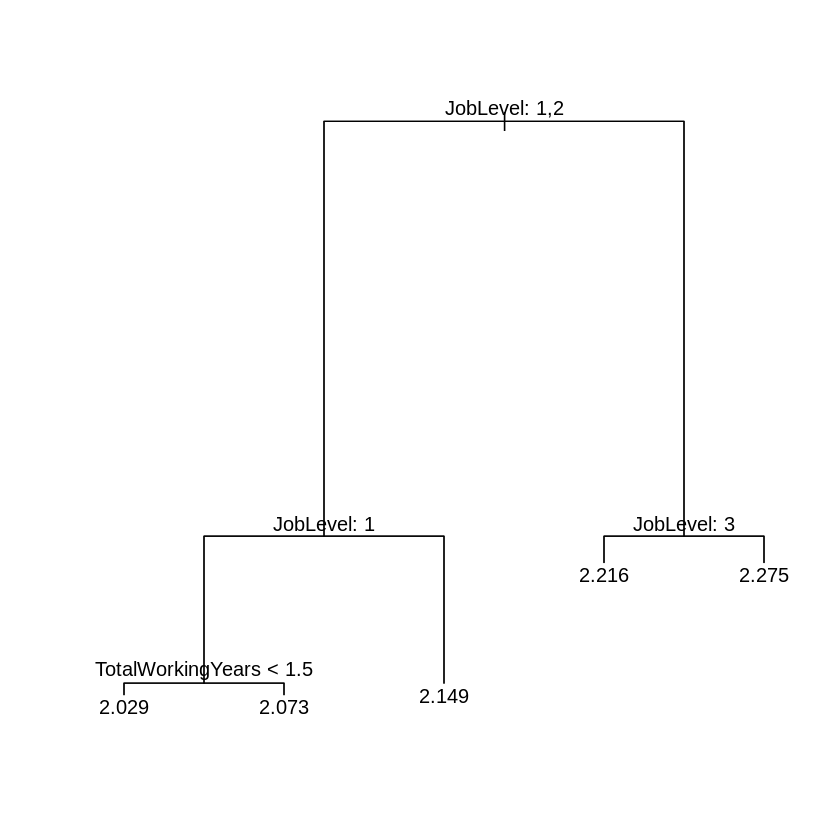

In [11]:
# Try many knots and find the best delta[1]
cv.errors <- sapply(1:15, function(data_f) {
  fit <- glm(MonthlyIncome ~ ns(TotalWorkingYears, df = data_f), data = df)
  # LOOCV by default
  cv.glm(df, fit, K = 10)$delta[1]
})
K <- which.min(cv.errors)
K
min(cv.errors)

mod_df <- as.data.frame(df)

tree.df <- tree(MonthlyIncome ~ ., data = mod_df)
print(tree.df)
summary(tree.df)
plot(tree.df)
text(tree.df, pretty = 0)


[1] 0.0007848091

[1] 5

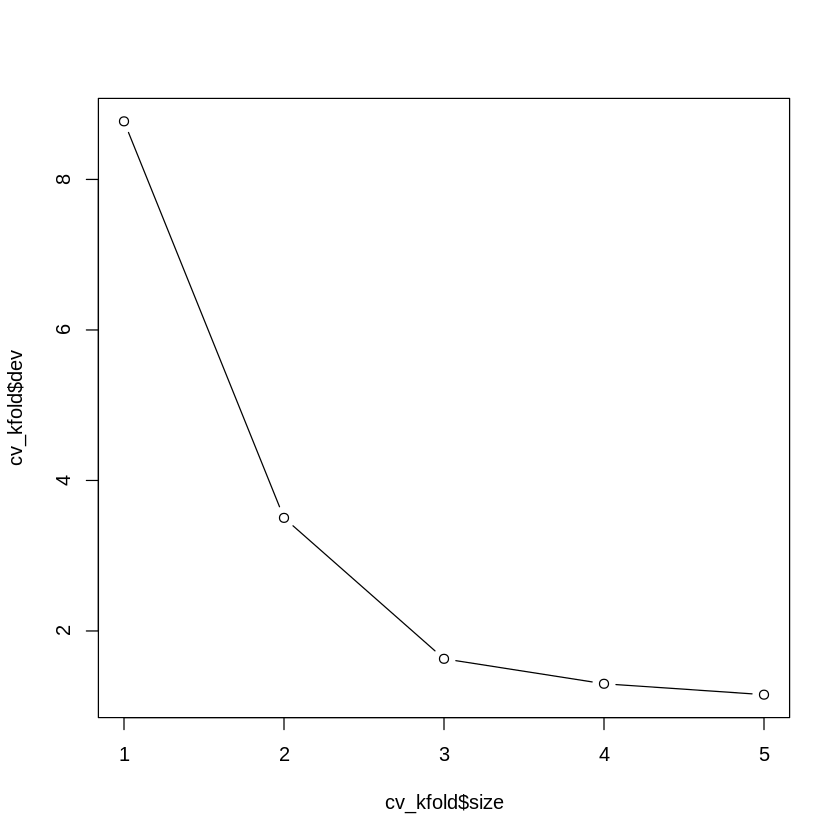

In [12]:
n <- nrow(mod_df)
set.seed(1)
cv_kfold <- cv.tree(tree.df, K = 10)
# cv_kfold$dev contains the sum of squared errors for each tree size, from a
# set of subtrees from tree.df.
# Index 1 corresponds to the largest tree, which is the original.
test_mse <- cv_kfold$dev[1] / n
test_mse
# type="b" creates both points and lines on the plot
plot(cv_kfold$size, cv_kfold$dev, type = "b")

best_index <- which.min(cv_kfold$dev)
best_size <- cv_kfold$size[best_index]
best_size


[1] 0.0007848091

[1] 0.0006886288


,%IncMSE,IncNodePurity
Age,-1.5052699,0.047714178
Attrition,-0.3814505,0.004883846
BusinessTravel,-4.5894686,0.011932946
DailyRate,0.5302137,0.074980263
Department,1.2332696,0.005403878
DistanceFromHome,0.7374892,0.041543783
Education,4.1426970,0.038382504
EducationField,-1.8625872,0.036023667
EmployeeNumber,-1.8123556,0.076702365
EnvironmentSatisfaction,-4.7136603,0.027014850


[1] 0.0006872477


,%IncMSE,IncNodePurity
Age,13.2516594,0.284358106
Attrition,2.6477155,0.012572649
BusinessTravel,0.1758905,0.015997234
DailyRate,-0.2367108,0.072816847
Department,8.4965027,0.028087269
DistanceFromHome,1.2541621,0.047540525
Education,4.3099587,0.042564430
EducationField,-1.4637661,0.041263523
EmployeeNumber,-1.9431308,0.075044957
EnvironmentSatisfaction,-3.2931938,0.032553697


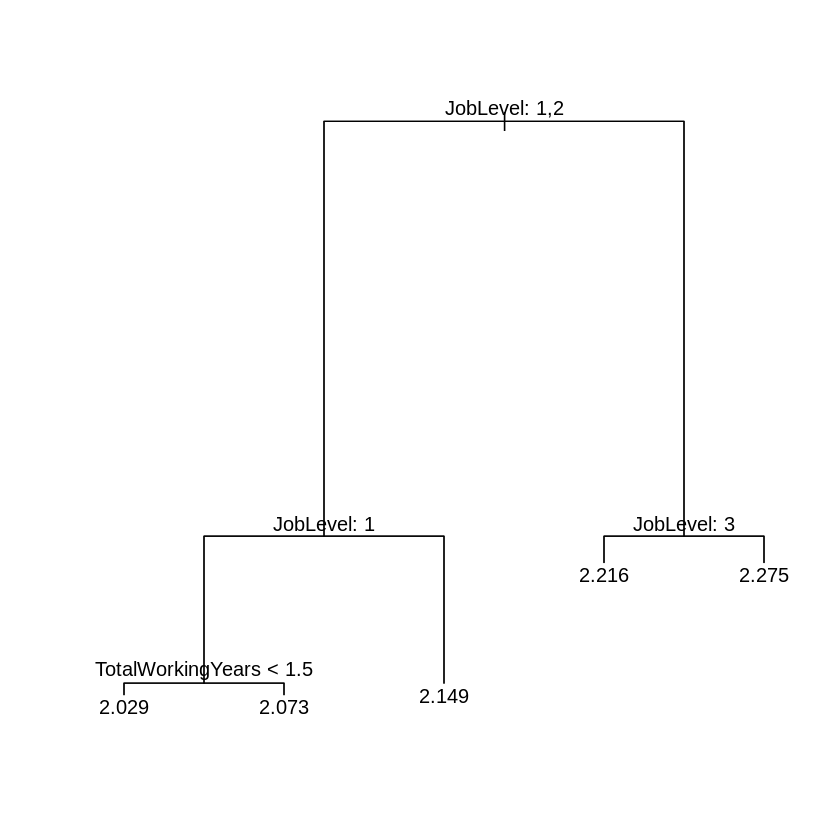

[1] 0.0006880087

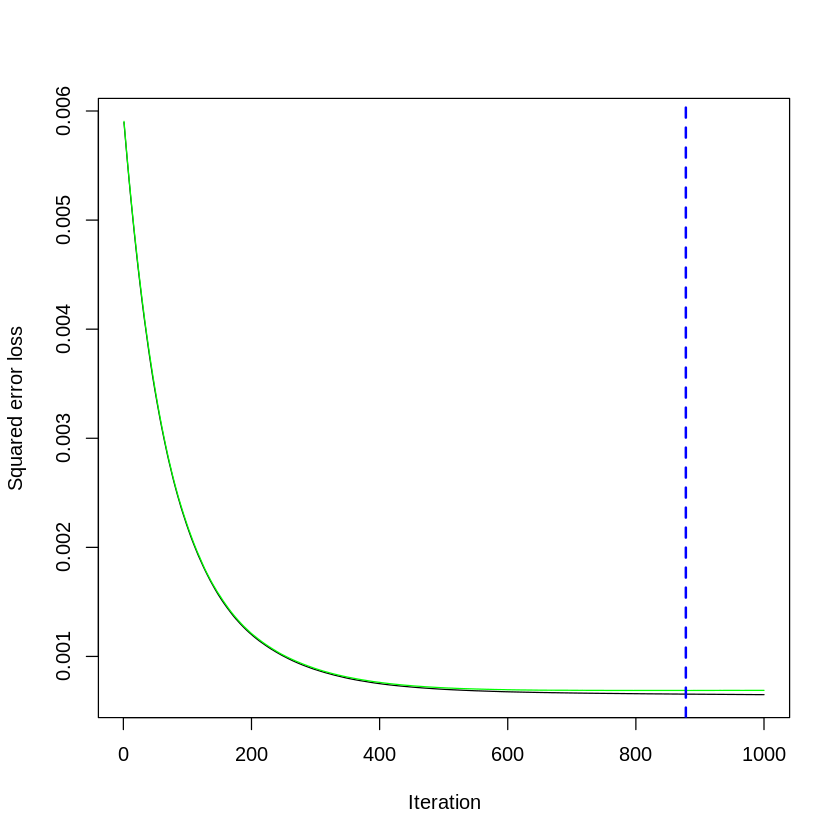

,var,rel.inf
,<chr>,<dbl>
JobLevel,JobLevel,74.384969769
JobRole,JobRole,20.161458211
TotalWorkingYears,TotalWorkingYears,4.454826710
Age,Age,0.330928417
DailyRate,DailyRate,0.128070352
YearsAtCompany,YearsAtCompany,0.073889911
YearsInCurrentRole,YearsInCurrentRole,0.071870310
JobInvolvement,JobInvolvement,0.066832175
HourlyRate,HourlyRate,0.054888343


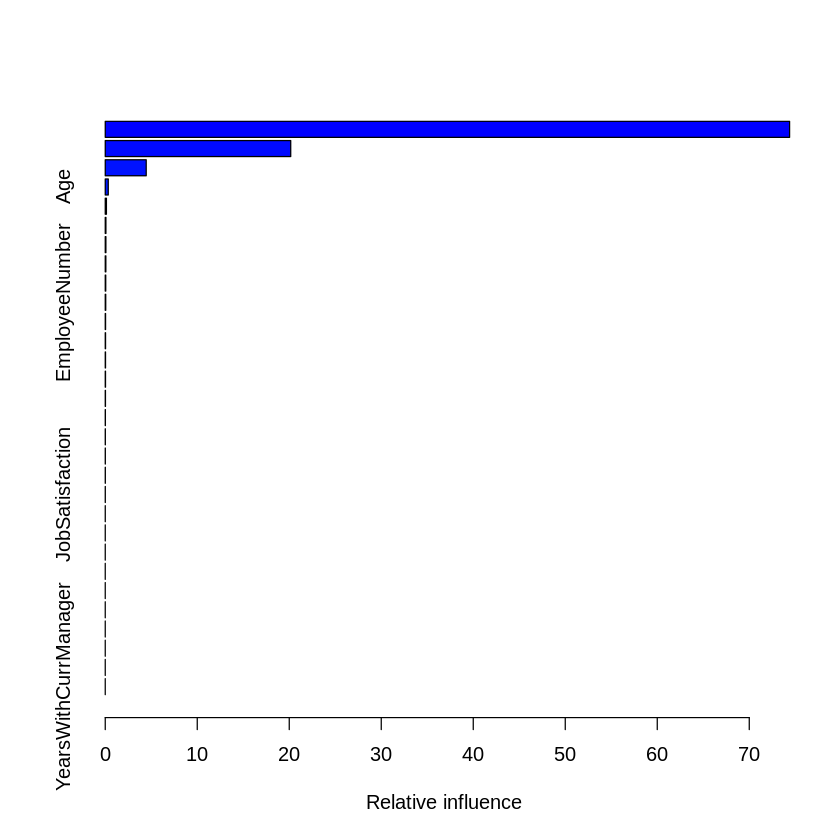

In [13]:
pruned_tree <- prune.tree(tree.df, best = best_size)
plot(pruned_tree)
text(pruned_tree, pretty = 0)
best_test_mse <- cv_kfold$dev[best_index] / n
best_test_mse

forest <- function(numpred) {
  bag.df <- randomForest(MonthlyIncome ~ ., data = df, mtry = numpred,
                              ntree = 1000, importance = TRUE)
  # Since we dont want data leakage, we use out of bag cv.
  # We get the 1000th entry, or the error of the complete collection
  # of 1000 trees
  test_mse_oob <- bag.df$mse[1000]
  print(test_mse_oob)
  importance(bag.df)
}
# bagging is just random forest but with all predictors (using mtry)
forest(ncol(df) - 1)
forest(floor((ncol(df) - 1) / 3))
# gaussian for regression
boost.df <- gbm(MonthlyIncome ~ ., data = df, distribution = "gaussian",
                     n.trees = 1000, interaction.depth = 1, shrinkage = 0.01,
                     cv.folds = 10)
best_tree <- gbm.perf(boost.df, method = "cv")
boost_mse <- boost.df$cv.error[best_tree]
boost_mse
summary(boost.df)

In [16]:
# SVC/SVM should always be scaled because they are dependent on magnitude
# I took out duplicates because it messed up the errors since the radial model
# just overfits to the data it has already seen. Since there was this data
# leakage we use unique to discard duplicates
df <- unique(df)
run_svc <- function(type, deg) {
  cat("TUNING")
  tune_out <- tune(svm, Attrition ~ ., data = df, kernel = type,
                   ranges = list(cost = c(0.001, 0.1, 1,
                   5, 50, 100)), degree = deg, scale = TRUE)
  print(summary(tune_out))
  optimal_cost <- tune_out$best.parameters$cost
  cat("BEST COST")
  print(optimal_cost)
  best_model <- tune_out$best.model
  cat("FINAL MODEL")
  print(summary(best_model))
}
# Could have done linear, but this allows me to create a function to do both
run_svc("polynomial", 1)
run_svc("polynomial", 2)

print("TUNING")
# R performs grid search on cost and gamma
tune_out <- tune(svm, Attrition ~ ., data = df, kernel = "radial",
               ranges = list(cost = c(0.1, 1, 10),
               gamma = c(0.01, 0.1, 1)),
               scale = TRUE)
print(summary(tune_out))
optimal_cost <- tune_out$best.parameters$cost
optimal_gamma <- tune_out$best.parameters$gamma
cat("BEST COST")
print(optimal_cost)
cat("BEST GAMMA")
print(optimal_gamma)
best_model <- tune_out$best.model
cat("FINAL MODEL")
print(summary(best_model))


TUNING
Parameter tuning of ‘svm’:

- sampling method: 10-fold cross validation 

- best parameters:
 cost
   50

- best performance: 0.1333333 

- Detailed performance results:
   cost     error dispersion
1 1e-03 0.1612245 0.03781481
2 1e-01 0.1612245 0.03781481
3 1e+00 0.1612245 0.03781481
4 5e+00 0.1598639 0.03574577
5 5e+01 0.1333333 0.02743670
6 1e+02 0.1360544 0.02868279

BEST COST[1] 50
FINAL MODEL
Call:
best.tune(METHOD = svm, train.x = Attrition ~ ., data = df, ranges = list(cost = c(0.001, 
    0.1, 1, 5, 50, 100)), kernel = type, degree = deg, scale = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  polynomial 
       cost:  50 
     degree:  1 
     coef.0:  0 

Number of Support Vectors:  480

 ( 226 254 )


Number of Classes:  2 

Levels: 
 No Yes



TUNING
Parameter tuning of ‘svm’:

- sampling method: 10-fold cross validation 

- best parameters:
 cost
    5

- best performance: 0.1544218 

- Detailed performance results:
   cost     error dispersion
1 

Cluster,Age,DailyRate,DistanceFromHome,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,34.98498,805.6617,9.250883,1035.9337,66.20936,2.115686,14343.45,2.618375,15.20583,8.55477,2.806537,5.321555,3.409894,1.522968,3.424028
2,43.41716,791.8491,8.997041,987.7959,64.82544,2.235493,14211.48,2.943787,15.22189,20.40533,2.775148,12.656805,6.973373,4.414201,6.464497


Cluster_km,Age,DailyRate,DistanceFromHome,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,34.39163,802.6093,9.360930,1044.5470,65.96372,2.109349,14264.48,2.575814,15.23814,7.946047,2.821395,4.869767,3.149767,1.309767,3.134884,1.041860
2,43.81519,802.1494,8.734177,971.3013,65.69367,2.235450,14445.43,3.012658,15.13165,20.351899,2.739241,12.827848,7.167089,4.577215,6.812658,1.741772


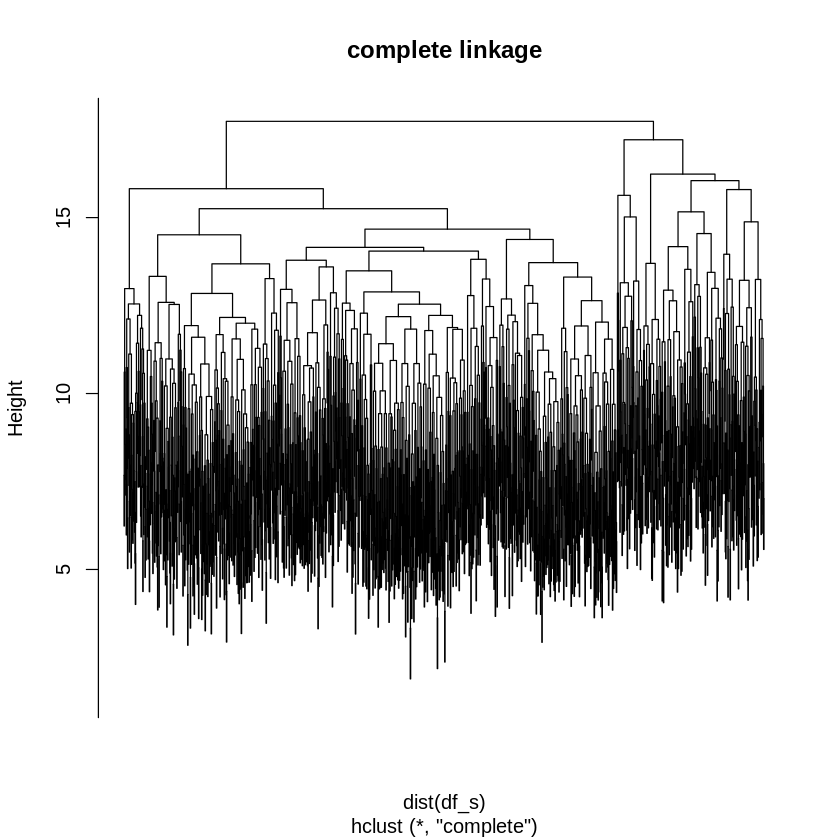

In [15]:
# turn into matrix to handle categorical variables, otherwise R throws an error
# when trying to scale
df_m <- model.matrix(~ . - 1, data = df)
df_s <- scale(df_m)
hcluster <- hclust(dist(df_s), method = "complete")
# no labels because it is very messy
plot(hcluster, main = "complete linkage", labels = FALSE)
clusters <- cutree(hcluster, 2)
df$Cluster <- clusters

# R throws error if not numeric
is_num <- sapply(df, is.numeric)
df_numeric <- df[, is_num]
# The . is used to calculate the mean for every variable against Cluster,
# the function is set to mean to get the mean for each predictor
aggregate(. ~ Cluster, data = df_numeric, FUN = mean)

km <- kmeans(df_s, 2)
df$Cluster_km <- km$cluster

is_num <- sapply(df, is.numeric)
df_numeric <- df[, is_num]
aggregate(. ~ Cluster_km, data = df_numeric, FUN = mean)